# CS 329A: Homework 2
### Code Generation and Verification

In this homework, we will explore the capabilities of LLMs in generating and verifying code. You will implement different test-time verification techniques, from simple zero-shot generation to more advanced methods like multi-candidate sampling and LLM-as-a-judge verification.

Objectives:
- Establish a baseline for an LLM's code generation performance.
- Implement and evaluate the pass@k metric by sampling multiple solutions.
- Build an LLM-as-a-Judge to select the best code candidate.
- Use an LLM to generate unit tests and perform "weak verification."
- Analyze the strengths and weaknesses of each approach.

#### Q1: Zero Shot (20 pts)
- 1a: Zero Shot Accuracy Code (15 pts)
- 1b: Written Analysis (5 pts)

#### Q2: Advanced Verification Techniques (40 pts)
- 2a: Pass@K Code (10 pts)
- 2b: LLM as Judge Code (20 pts)
- 2c: Evaluating Judge Code (10 pts)

#### Q3: Unit Test Generation and Weak Verifiers (50 pts)
- 3a: Unit Test Generator Code (20 pts)
- 3a: Evaluate Ground Truth of LLM Tests Code (10 pts)
- 3a: Written Analysis (10 pts)
- 3b: K-shot Accuracy on LLM tests (10 pts)

In [1]:
from cs329_hw.tasks import HumanEval
from cs329_hw.methods import get_sampler
from cs329_hw.run.sandbox import run_python   # local subprocess sandbox (no Docker required)
from cs329_hw.methods.verifiers import HumanEvalVerifier, TestCase
from cs329_hw.methods.llm_unit_test import LLMUnitTestGeneratorConfig, LLMUnitTestGenerator

import os
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

# debug mode runs your code on a subset of the test set for faster iteration
# (set env HW_DEBUG=1 to enable; default False runs the full 164-problem set)
DEBUG_MODE = os.getenv("HW_DEBUG", "False").lower() in ("1", "true", "yes")
print(f"DEBUG_MODE={DEBUG_MODE}")

DEBUG_MODE=False


In [2]:
# Include the following line to reload the modules when you make changes
# (helpful when iterating on code locally)

%load_ext autoreload
%autoreload 2

In [3]:
import os
from dotenv import load_dotenv
# API keys are read from the environment (exported before launch). We still load
# environment.env / .env if present, but do not hard-fail when they are absent.
load_dotenv()
load_dotenv(dotenv_path="environment.env")

# model path for generation and judging (swapped from Together/Qwen to Claude)
qwen_path = "anthropic/claude-haiku-4-5"

### HumanEval Dataset Setup
We will be working with the [HumanEval](https://arxiv.org/abs/2107.03374) benchmark to evaluate model performance on various coding tasks. The dataset contains 164 problems, each with a function signature, a descriptive docstring, and a set of unit tests to verify the correctness of the generated code.

In [4]:
humaneval = HumanEval()
problems = humaneval.get_problems(debug_mode=DEBUG_MODE)
system_prompt = humaneval.get_system_prompt()

#### Dataset exploration

Each problem in the dataset is provided as a dictionary containing the problem description, answer, and a set of unit tests.

In [5]:
example_docstring = problems[1]["problem"]
example_solution = problems[1]["answer"]
example_test_suite = problems[1]["test_suite"]
print("========Docstring========", example_docstring)
print("========Example solution======== \n", example_solution)
print("========Provided tests========\n", example_test_suite)

========Docstring======== 
def unique_digits(x):
    """Given a list of positive integers x. return a sorted list of all 
    elements that hasn't any even digit.

    Note: Returned list should be sorted in increasing order.
    
    For example:
    >>> unique_digits([15, 33, 1422, 1])
    [1, 15, 33]
    >>> unique_digits([152, 323, 1422, 10])
    []
    """

========Example solution======== 
     odd_digit_elements = []
    for i in x:
        if all (int(c) % 2 == 1 for c in str(i)):
            odd_digit_elements.append(i)
    return sorted(odd_digit_elements)

========Provided tests========
 def check(candidate):

    # Check some simple cases
    assert_(candidate([15, 33, 1422, 1]) == [1, 15, 33], 'candidate([15, 33, 1422, 1]) == [1, 15, 33]')
    assert_(candidate([152, 323, 1422, 10]) == [], 'candidate([152, 323, 1422, 10]) == []')
    assert_(candidate([12345, 2033, 111, 151]) == [111, 151], 'candidate([12345, 2033, 111, 151]) == [111, 151]')
    assert_(candidate([135, 103

To help you build a few different kinds of verifiers, we have provided the following tools.

In [6]:
verifier = HumanEvalVerifier(runner=run_python, timeout_s=2)

# before we run the code, we must combine the function docstring with the solution
docstring_and_correct_solution = f"{example_docstring}\n{example_solution}"
docstring_and_incorrect_solution = f"{example_docstring}\n    return False"

res = verifier.verify( 
    code=docstring_and_incorrect_solution, # swap this to docstring_and_correct_solution to see what a passing solution output looks like
    function_name=problems[1]["function_name"],
    test_suite=example_test_suite
)
verifier.print_verification_result(res)

=== Verification Result ===
passed_all: False
num_passed/num_total: 1 / 5
--- stdout ---
__CASE__ 1 FAIL candidate([15, 33, 1422, 1]) == [1, 15, 33]
__CASE__ 2 FAIL candidate([152, 323, 1422, 10]) == []
__CASE__ 3 FAIL candidate([12345, 2033, 111, 151]) == [111, 151]
__CASE__ 4 FAIL candidate([135, 103, 31]) == [31, 135]
__CASE__ 5 PASS
__RESULT__=FAIL
__COUNTS__= 1 / 5
__TIME__= 9.059906005859375e-06
time_s: 0.0262


### LLM Sampling

To generate code, we'll use a sampler function that can request multiple completions for a single prompt; this is the basis of the techniques that we will implement.

The `get_sampler("sample_multiple", n_samples=k, ...)` method returns a list of lists, where for each prompt that is passed as an input, we return a list of `k` responses.

In [7]:
method = get_sampler(
    "sample_multiple",
    qwen_path,
    temperature=0.7,
    system_prompt=system_prompt,  # IMPORTANT: use the provided system prompt
    n_samples=3
)
prompts = [example_docstring]
responses = method(prompts)
for i, response in enumerate(responses[0]):
    print(f"========Response {i+1}========")
    print(response)

========Response 1========
```python
def unique_digits(x):
    """Given a list of positive integers x. return a sorted list of all 
    elements that hasn't any even digit.

    Note: Returned list should be sorted in increasing order.
    
    For example:
    >>> unique_digits([15, 33, 1422, 1])
    [1, 15, 33]
    >>> unique_digits([152, 323, 1422, 10])
    []
    """
    result = []
    
    for num in x:
        # Check if the number has any even digit
        has_even_digit = False
        for digit in str(num):
            if int(digit) % 2 == 0:
                has_even_digit = True
                break
        
        # If no even digit found, add to result
        if not has_even_digit:
            result.append(num)
    
    return sorted(result)
```
========Response 2========
```python
def unique_digits(x):
    """Given a list of positive integers x. return a sorted list of all 
    elements that hasn't any even digit.

    Note: Returned list should be sorted in increasi

Notice that the LLM's output includes Markdown code fences (e.g., ```python``). We need to remove these before we can execute the code.

In [8]:
import re

def extract_code(text: str) -> str:
    """Removes python code, demarcated by ```python and ```, from LLM output."""
    if not text:
        return ""
    text = re.sub(r"```(?:python)?\s*", "", text)
    text = text.replace("```", "")
    return text.strip()


cleaned_responses = [extract_code(resp) for resp in responses[0]]
for i, response in enumerate(responses[0]):
    print(f"========Cleaned response {i+1}========")
    print(cleaned_responses[i])

========Cleaned response 1========
def unique_digits(x):
    """Given a list of positive integers x. return a sorted list of all 
    elements that hasn't any even digit.

    Note: Returned list should be sorted in increasing order.
    
    For example:
    >>> unique_digits([15, 33, 1422, 1])
    [1, 15, 33]
    >>> unique_digits([152, 323, 1422, 10])
    []
    """
    result = []
    
    for num in x:
        # Check if the number has any even digit
        has_even_digit = False
        for digit in str(num):
            if int(digit) % 2 == 0:
                has_even_digit = True
                break
        
        # If no even digit found, add to result
        if not has_even_digit:
            result.append(num)
    
    return sorted(result)
========Cleaned response 2========
def unique_digits(x):
    """Given a list of positive integers x. return a sorted list of all 
    elements that hasn't any even digit.

    Note: Returned list should be sorted in increasing order

Finally, let's verify one of the cleaned responses to see if it's correct.

In [9]:
res = verifier.verify(
    code=cleaned_responses[1], # you can edit the index here to try each of the three responses
    function_name=problems[1]["function_name"],
    test_suite=example_test_suite,
)
verifier.print_verification_result(res)

=== Verification Result ===
passed_all: True
num_passed/num_total: 5 / 5
--- stdout ---
__CASE__ 1 PASS
__CASE__ 2 PASS
__CASE__ 3 PASS
__CASE__ 4 PASS
__CASE__ 5 PASS
__RESULT__=OK
__COUNTS__= 5 / 5
__TIME__= 2.384185791015625e-05
time_s: 0.0216


### Part 1: Zero-shot predictions (20 pts)
- 1a: Zero Shot Accuracy Code (15 pts)
- 1b: Written Analysis (5 pts)

First, we will evaluate the baseline accuracy of the predictions with a single zero-shot sample.

Deliverable:

* Write your code in the section specified by `TODO: YOUR CODE STARTS HERE` and `TODO: YOUR CODE ENDS HERE`.
* Report the accuracy of the predictions below.

Hint: Look at the entries of the verifier.verify() dictionary

In [10]:
def calculate_accuracy(predictions:list[str], problems: list[dict], verifier: HumanEvalVerifier):
    """
    Calculates the zero-shot accuracy of code predictions.

    Args:
        predictions: A list of generated code strings, one for each problem.
        problems: The list of HumanEval problem dictionaries.
        verifier: The HumanEvalVerifier instance.

    Returns:
        A tuple containing:
        - accuracy (float): The fraction of correctly solved problems (i.e. passed all unit tests).
        - response (list[str]): A list of the verifier's `stdout` field, containing the results of each problem.
        - wrong (list[int]): A list of indices for the problems that failed.
    """
    ### TODO: YOUR CODE STARTS HERE
    correct = 0
    response = []
    incorrect_indices = []
    for i, (code, problem) in enumerate(zip(predictions, problems)):
        if code is None:  # e.g. judge declined to pick a candidate
            response.append("")
            incorrect_indices.append(i)
            continue
        result = verifier.verify(code, problem["function_name"], problem["test_suite"])
        response.append(result["stdout"])
        if result["passed_all"]:
            correct += 1
        else:
            incorrect_indices.append(i)
    accuracy = correct / len(problems) if problems else 0.0
    ### TODO: YOUR CODE ENDS HERE
    return accuracy, response, incorrect_indices

In [11]:
method = get_sampler("sample_multiple",qwen_path, temperature=0.7, n_samples=1, system_prompt=system_prompt)
prompts = [entry["problem"] for entry in problems]
predictions_all_probs_zero_shot = method(prompts)
cleaned_predictions_zero_shot = [extract_code(raw_code[0]) for raw_code in predictions_all_probs_zero_shot]
accuracy, response, wrong = calculate_accuracy(cleaned_predictions_zero_shot, problems, verifier)

print(f"Accuracy: {accuracy}")
print(f"Indices of failed problems: {wrong}")
print(f"Unit test results of all problems: {response}")

Accuracy: 0.8414634146341463
Indices of failed problems: [4, 5, 17, 20, 22, 26, 30, 33, 36, 38, 48, 53, 80, 82, 97, 113, 118, 124, 134, 137, 143, 146, 150, 156, 161, 162]
Unit test results of all problems: ['__CASE__ 1 PASS\n__CASE__ 2 PASS\n__CASE__ 3 PASS\n__CASE__ 4 PASS\n__CASE__ 5 PASS\n__CASE__ 6 PASS\n__CASE__ 7 PASS\n__CASE__ 8 PASS\n__CASE__ 9 PASS\n__CASE__ 10 PASS\n__CASE__ 11 PASS\n__CASE__ 12 PASS\n__RESULT__=OK\n__COUNTS__= 12 / 12\n__TIME__= 1.5735626220703125e-05\n', '__CASE__ 1 PASS\n__CASE__ 2 PASS\n__CASE__ 3 PASS\n__CASE__ 4 PASS\n__CASE__ 5 PASS\n__RESULT__=OK\n__COUNTS__= 5 / 5\n__TIME__= 1.5020370483398438e-05\n', '__CASE__ 1 PASS\n__CASE__ 2 PASS\n__CASE__ 3 PASS\n__CASE__ 4 PASS\n__CASE__ 5 PASS\n__CASE__ 6 PASS\n__CASE__ 7 PASS\n__RESULT__=OK\n__COUNTS__= 7 / 7\n__TIME__= 1.4066696166992188e-05\n', '__CASE__ 1 PASS\n__CASE__ 2 PASS\n__CASE__ 3 PASS\n__RESULT__=OK\n__COUNTS__= 3 / 3\n__TIME__= 8.106231689453125e-06\n', '', '', '__CASE__ 1 PASS\n__CASE__ 2 PASS\

##### 1b) Experiment with different problems and any failed tests cases. Explain in a few sentences what sorts of patterns do you observe among the failed test cases. What are some possible reasons that the generated code fails these test cases?

**Answer** (full 164-problem zero-shot run with `anthropic/claude-haiku-4-5`: accuracy **0.841**, 26 failures)

Two clear patterns dominate the 26 failures:

1. **Output-formatting / parse failures (~19 of 26).** These problems fail with a `SyntaxError`/non-zero exit (`returncode:1`) rather than a wrong answer. At temperature 0.7 the model sometimes *thinks out loud* or revises mid-answer and leaves natural language **outside** code fences — e.g. `order_by_points`, `tri`, and `find_max` all contain a literal line like `Wait, let me reconsider ...` in the emitted program. The provided `extract_code` only strips ```` ``` ```` fences, so any leaked prose (or a second draft) becomes invalid Python and the whole solution crashes before a single assert runs.

2. **Edge-case logic errors (~7 of 26).** Here the code runs but fails a *few* asserts: `is_nested` passed 12/14, `is_simple_power` passed 9/10. The model captures the main idea but mishandles boundary conditions (empty input, the `n==1` / `power==1` special case, nesting tie-breaks).

**Why it fails:** (1) *instruction-following at temperature* — the system prompt asks for fenced code only, but sampling occasionally produces reasoning or multiple candidates that our simple regex can't clean; (2) *genuine reasoning gaps on the hard problems* — the secondary/edge rules of the spec are approximated rather than implemented exactly. Note that (1) is largely recoverable by re-sampling, which is exactly why pass@k jumps to 0.915 (k=3) → 0.939 (k=9).

### Part 2: Advanced Verification Techniques (40 pts)
- 2a: Pass@K Code (10 pts)
- 2b: LLM as Judge Code (20 pts)
- 2c: Evaluating Judge Code (10 pts)

 In this section, we'll explore more sophisticated techniques to improve our success rate.

#### 2a) Parallel Sampling and pass@K

Instead of generating just one solution, we want to independently generate `k` different solutions and check if any of them are correct. Here, we use `k=3`.

In [12]:
method = get_sampler("sample_multiple", qwen_path, temperature=0.7, n_samples=3, system_prompt=system_prompt)
prompts = [entry["problem"] for entry in problems]
preds_3shot = method(prompts)
cleaned_preds_3shot = [ # list[list[str]] here, where each inner list[str] contains the k code samples for that problem
    [extract_code(code) for code in raw_codes]
    for raw_codes in preds_3shot
]

Fill in the `k_shot_acc` function, which computes pass@k i.e. the proportion of problems for which a correct solution is obtained within `k` attempts.

In [13]:
def k_shot_acc(predictions: list[list[str]], problems: list[dict], verifier):
    """
    Calculates pass@k accuracy. A problem is solved if any of its k candidates pass.

    Args:
        predictions (list[list[str]]): A list where each item is another list of k code strings for a problem.
        problems (list[dict]): The list of HumanEval problem dictionaries.
        verifier (HumanEvalVerifier): The HumanEvalVerifier instance.

    Returns:
        A tuple containing:
        - accuracy (float): The pass@k accuracy.
        - solved_fns (list[str]): A list of function names for problems that were solved.
    """
    num_probs = len(predictions)
    num_corr = 0
    solved_fns = []

    ### TODO: YOUR CODE STARTS HERE
    for preds, problem in zip(predictions, problems):
        # A problem is solved if ANY of its k candidates passes all tests.
        solved = False
        for code in preds:
            if code is None:
                continue
            result = verifier.verify(code, problem["function_name"], problem["test_suite"])
            if result["passed_all"]:
                solved = True
                break
        if solved:
            num_corr += 1
            solved_fns.append(problem["function_name"])
    ### TODO: YOUR CODE ENDS HERE
    accuracy = num_corr / num_probs if num_probs > 0 else 0.0
    return accuracy, solved_fns

accuracy_3shot, _ = k_shot_acc(cleaned_preds_3shot, problems, verifier)
print(f"3-shot accuracy: {accuracy_3shot}")

3-shot accuracy: 0.9146341463414634


Observe how pass@k varies as we change the number of generated samples for k = 3, 6, and 9.

Accuracy (6-shot): 0.927


Accuracy (9-shot): 0.939


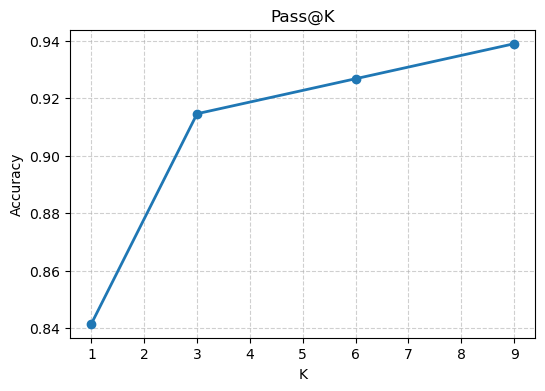

In [14]:
import matplotlib.pyplot as plt
from tqdm import tqdm

def sample_and_evaluate(k: int):
    """Samples k code completions per problem and compute accuracy."""
    method = get_sampler(
        "sample_multiple",
        qwen_path,
        temperature=0.7,
        n_samples=k,
        system_prompt=system_prompt
    )
    prompts = [entry["problem"] for entry in problems]
    preds = method(prompts)
    cleaned_preds = [[extract_code(code) for code in raw_codes] for raw_codes in preds]
    acc, _ = k_shot_acc(cleaned_preds, problems, verifier)
    return acc


sample_sizes = [1, 3, 6, 9]
accuracies = [accuracy, accuracy_3shot]  # Start with your existing 3-shot accuracy

# Run for k = 6 and 9
for k in sample_sizes[2:]:
    acc = sample_and_evaluate(k)
    accuracies.append(acc)
    print(f"Accuracy ({k}-shot): {acc:.3f}")

# Plot results
plt.figure(figsize=(6, 4))
plt.plot(sample_sizes, accuracies, marker="o", linewidth=2)
plt.title("Pass@K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

#### 2b) LLM-as-a-Judge Verification
For some tasks, executing code can be slow and resource-intensive. An alternative is to use another LLM as a "judge" to review the candidate solutions and select the one it deems most likely to be correct. This leverages the model's understanding of code quality and logic without requiring execution.

Your task is to implement the `judge` and `_build_messages` methods in the `LLMJudge` class.

- `_build_messages`: Construct the prompt that will be sent to the judge LLM. It should include the problem specification and the formatted candidate solutions.

- `judge`: Use the sampler to send the prompt to the judge and parse its JSON response to extract the chosen index and reasoning.

In [15]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable, List, Dict, Any, Optional, Tuple
import json
import re
from collections import Counter
from cs329_hw.methods.simple_samplers import SampleMultiple


@dataclass
class JudgeConfig:
    temperature: float = 0.7   # sampling temp you set inside your sampler
    max_choices: int = 10      # safety cap for number of candidate codes

class LLMJudge:
    """
    LLM-as-a-judge that selects the index of the best code snippet from a list of candidate completions.
    If no candidate seems correct, the LLM returns None.
    """

    def __init__(self, sampler: SampleMultiple, cfg: JudgeConfig = JudgeConfig(), model_name: str = qwen_path):
        self.sampler = sampler
        self.cfg = cfg
        self.model_name = model_name

    def judge(
        self,
        problem_prompt: str,
        function_name: str,
        code_snippets: List[str],
    ) -> Dict[str, Any]:
        """
        Orchestrates the judging process by building a prompt, querying the LLM, and parsing the response.

        Your implementation should follow these steps:
        1. Call `self._build_messages()` to construct the detailed prompt for the LLM-based judge, which 
            includes the code snippets to be judged.
        2. Use `self.sampler` to send this prompt to the LLM and get its raw response.
        3. Call `self._parse_json_choice()` to robustly extract the judge's decision from the raw text.
            
        Args:
            problem_prompt (str): The problem specification.
            function_name (str): The name of the target function.
            code_snippets (List[str]): A list of candidate code snippets.

        Returns:
            A dictionary containing:
            - "choice": the int index of the chosen code snippet, or None
            - "reason": the stripped string that describes why the model chose the option
            - "raw_response": the raw response from the LLM for debugging
        """
        assert 1 <= len(code_snippets) <= self.cfg.max_choices

        ### TODO: YOUR CODE STARTS HERE
        # 1) Build the judge prompt, 2) query the LLM, 3) parse the JSON decision.
        prompt = self._build_messages(problem_prompt, function_name, code_snippets)
        raw_response = self.sampler([prompt])[0][0]
        final_choice, reason = self._parse_json_choice(raw_response)
        if final_choice is not None and not (0 <= final_choice < len(code_snippets)):
            final_choice = None  # ignore out-of-range indices
        ### TODO: YOUR CODE ENDS HERE
        
        return {"choice": final_choice, "reason": reason, "raw_response": raw_response}

    def _build_messages(self, problem_prompt: str, function_name: str, code_snippets: List[str]) -> str:
        """
        Builds the full text prompt for the LLM-as-a-judge model.

        Your prompt should include:
        - A message describing the LLM judge's behavior as a code evaluator
        - The problem statement (`problem_prompt`) and target function name (`function_name`)
        - The list of all candidate code snippets the LMM judge will choose from (`code_snippets`)
        - Instructions about choosing the most correct code
        - Examples of the expected response format.
          
        The LLM judge should be prompted to return a single-line JSON object with this exact schema (no prose before/after):
        {{
        "choice": <integer index or null>,
        "reason": "<one short sentence>"
        }}

        Expected Output:
          The returned string should contain both the system prompt and user instructions,
          ready to be passed into the LLM sampler.
        """

        ### TODO: YOUR CODE STARTS HERE
        listed = "\n\n".join(
            f"Candidate [{i}]:\n```python\n{code}\n```"
            for i, code in enumerate(code_snippets)
        )
        prompt = (
            "You are a meticulous Python code reviewer acting as a judge. You are given a "
            "programming problem and several candidate implementations of a function. "
            "Decide which single candidate is most likely to be a fully correct solution.\n\n"
            f'Problem specification:\n"""\n{problem_prompt}\n"""\n\n'
            f"Target function name: {function_name}\n\n"
            f"Candidates (indices 0..{len(code_snippets) - 1}):\n{listed}\n\n"
            "Choose the index of the best (most correct) candidate. If NONE of them look "
            "correct, choose null.\n"
            "Respond with a SINGLE line of JSON and nothing else, exactly in this schema:\n"
            '{"choice": <integer index or null>, "reason": "<one short sentence>"}\n\n'
            "Examples:\n"
            '{"choice": 0, "reason": "Handles all edge cases correctly."}\n'
            '{"choice": null, "reason": "All candidates fail on empty input."}'
        )
        ### TODO: YOUR CODE ENDS HERE
        
        return prompt
        


    def _parse_json_choice(self, raw: str) -> Tuple[Optional[int], str]:
        """
        Robustly extracts the judge's choice and reason from the raw LLM text response.

        Args:
            raw (str): The raw text output from the LLM judge.

        Returns:
            A tuple containing:
                - Optional[int]: The chosen index (or None if unparseable, None-chosen, or invalid)
                - str: The LLM's reasoning for the choice
        """
        if not raw or not raw.strip():
            return None, "Empty response"

        first = raw.strip().splitlines()[0].strip()
        obj = None
        try:
            obj = json.loads(first)
        except Exception:
            m = re.search(r"\{.*\}", raw, flags=re.DOTALL)
            if m:
                try:
                    obj = json.loads(m.group(0))
                except Exception:
                    obj = None

        if not isinstance(obj, dict):
            return None, "Unparseable"

        choice = obj.get("choice", None)
        reason = obj.get("reason", "")
        if choice is None:
            return None, reason or "None"

        try:
            idx = int(choice)
            return (idx if idx >= 0 else None), reason
        except Exception:
            return None, reason or "Non-integer index"

To test this implementation, we can apply the LLM-as-a-judge to the 3 responses we sampled for the first HumanEval problem in the LLM Sampling section.

In [16]:
judge_method = get_sampler("sample_multiple", qwen_path, temperature=1, n_samples=1)

judge = LLMJudge(sampler=judge_method, cfg=JudgeConfig(temperature=0.7), model_name=qwen_path)

candidates = cleaned_preds_3shot[0]
decision = judge.judge(problems[0]["problem"], problems[0]["function_name"], candidates)
print("Problem:", problems[0]["problem"])
for i, candidate in enumerate(candidates):
    print(f"Candidate {i}: {candidate}")
    print("---"*50)
print("Judge choice:", decision["choice"])
print("Judge reason:", decision["reason"])


Problem: 

def correct_bracketing(brackets: str):
    """ brackets is a string of "(" and ")".
    return True if every opening bracket has a corresponding closing bracket.

    >>> correct_bracketing("(")
    False
    >>> correct_bracketing("()")
    True
    >>> correct_bracketing("(()())")
    True
    >>> correct_bracketing(")(()")
    False
    """

Candidate 0: def correct_bracketing(brackets: str):
    """ brackets is a string of "(" and ")".
    return True if every opening bracket has a corresponding closing bracket.

    >>> correct_bracketing("(")
    False
    >>> correct_bracketing("()")
    True
    >>> correct_bracketing("(()())")
    True
    >>> correct_bracketing(")(()")
    False
    """
    count = 0
    for char in brackets:
        if char == "(":
            count += 1
        elif char == ")":
            count -= 1
        
        # If count goes negative, we have a closing bracket without an opening one
        if count < 0:
            return False
    
   

#### 2c) Evaluating the Judge

Now, let's write a function to loop through all our problems, use the judge to select the best of the three candidates we generated earlier, and then calculate the final accuracy.

In [17]:
def evaluate_judge(problems: list[dict], code_generations: list[list[str]], judge:LLMJudge) -> list[str]:
    """
    Evaluates a set of generated code solutions using a given LLM judge.

    Args:
        problems (list[dict]): The list of HumanEval problem dictionaries.
        code_generations (list[list[str]]): A list where each element is a list of code samples for the corresponding problem.
        judge (LLMJudge): LLMJudge object

    Returns:
        A list containing the code snippet chosen by the judge for each problem.
        If the judge did not make a choice for a given problem, the corresponding
        element in the list will be `None`.
    """
    ### TODO: YOUR CODE STARTS HERE
    results = []
    for problem, candidates in zip(problems, code_generations):
        decision = judge.judge(problem["problem"], problem["function_name"], candidates)
        choice = decision["choice"]
        if choice is not None and 0 <= choice < len(candidates):
            results.append(candidates[choice])
        else:
            results.append(None)
    ### TODO: YOUR CODE ENDS HERE
    return results

code_generation_method = get_sampler(
    "sample_multiple",
    qwen_path,
    temperature=0.7,
    n_samples=3,
    system_prompt=system_prompt
)
judge_method = get_sampler("sample_multiple", qwen_path, temperature=1, n_samples=1)
judge = LLMJudge(sampler=judge_method, cfg=JudgeConfig(temperature=0.7), model_name=qwen_path)

cleaned_predictions_llm_judge = evaluate_judge(problems, cleaned_preds_3shot, judge)
accuracy, response, wrong = calculate_accuracy(cleaned_predictions_llm_judge, problems, verifier)
print(f"LLM Judge accuracy: {accuracy}")


LLM Judge accuracy: 0.7926829268292683


### Part 3: Unit Test Generation and Weak Verifiers (50 pts)
- 3a: Unit Test Generator Code (20 pts)
- 3a: Evaluate Ground Truth of LLM Tests Code (10 pts)
- 3a: Written Analysis (10 pts)
- 3b: K-shot Accuracy on LLM tests (10 pts)

So far, we've relied on the ground-truth test suite. In many real-world cases, we don't have access to this ground-truth test suite. In this section, we'll use an LLM to generate its own unit tests. This enables a pipeline with "weak verifiers", where we use these synthetic tests to filter and select code solutions.

#### Part 3a: Generating and Validating Unit Tests

First, let's assess how good the LLM is at writing tests. We will prompt it to generate 5 test cases for each problem based only on the docstring. Then, we'll run these tests against the ground-truth solution. The percentage of problems where the ground-truth code passes all synthetic tests gives us a measure of the LLM's ability to generate reliable tests.

**Note**: We use a more powerful model for test generation, as it is a more demanding task.

**Deliverable:** Fill out `LLMUnitTestGenerator._build_prompt()` and `LLMUnitTestGenerator.generate()` in `methods/llm_unit_test.py`

In [18]:
qwen_large = "anthropic/claude-sonnet-4-5"

# Here is an example of using the LLM-based unit test generator to create tests for one problem.
testgen_method = get_sampler(
    "sample_multiple",
    qwen_large, 
    temperature=1.0,
    n_samples=1,
    system_prompt="You are a careful Python unit test designer."
)
testgen = LLMUnitTestGenerator(sampler=testgen_method, cfg=LLMUnitTestGeneratorConfig())

doc = problems[0]["problem"]
fn  = problems[0]["function_name"]

cases = testgen.generate(problem_prompt=doc, function_name=fn, n_unit_tests=5)
candidate_code = f"{doc}\n{problems[0]['answer']}"

res = verifier.verify(code=candidate_code, function_name=fn, test_suite=cases)
HumanEvalVerifier.print_verification_result(res)

=== Verification Result ===
passed_all: True
num_passed/num_total: 5 / 5
--- stdout ---
__CASE__ 0 1 True True
__CASE__ 1 1 False False
__CASE__ 2 1 True True
__CASE__ 3 1 False False
__CASE__ 4 1 True True
__RESULT__=OK
__COUNTS__= 5 / 5
__TIME__= 1.0013580322265625e-05
time_s: 0.0122


In [19]:
def evaluate_ground_truth_on_llm_unit_tests(
    problems: list[dict],
    llm_unit_test_generator: LLMUnitTestGenerator,
    verifier: HumanEvalVerifier,
    n_unit_tests: int = 5
):
    """
    Generates unit tests using the LLMUnitTestGenerator and evaluates the ground-truth code against them.

    Returns:
        - accuracy (float): Percentage of problems where ground truth passed all synthetic tests.
        - correct_idxs (list[int]): The indices of the problems that passed the tests.
        - generated_unit_tests (list[list[TestCase]]): A list of test cases for each problem, where the outer list is over all problems.
    """
    num_problems = len(problems)
    num_correct = 0
    correct_idxs = []
    generated_unit_tests = []

    ### TODO: YOUR CODE STARTS HERE
    for i, problem in enumerate(problems):
        cases = llm_unit_test_generator.generate(
            problem_prompt=problem["problem"],
            function_name=problem["function_name"],
            n_unit_tests=n_unit_tests,
        )
        generated_unit_tests.append(cases)
        gt_code = f"{problem['problem']}\n{problem['answer']}"
        result = verifier.verify(gt_code, problem["function_name"], cases)
        # Require >0 tests so an empty test list is not counted as a vacuous pass.
        if result["passed_all"] and result["num_total"] > 0:
            num_correct += 1
            correct_idxs.append(i)
    ### TODO: YOUR CODE ENDS HERE

    accuracy = num_correct / num_problems if num_problems > 0 else 0.0
    print(f"Ground truth code passed all LLM-generated tests for {num_correct}/{num_problems} problems.")
    print(f"Accuracy: {accuracy}")
    return accuracy, correct_idxs, generated_unit_tests

accuracy, correct_idxs, generated_unit_tests = evaluate_ground_truth_on_llm_unit_tests(problems, testgen, verifier, n_unit_tests=5)

Ground truth code passed all LLM-generated tests for 126/164 problems.
Accuracy: 0.7682926829268293


We see that the LLM-generated unit tests are sometimes unreliable, where the ground-truth code fails to pass the synthetic tests. Let's examine one of these failures to see what went wrong.

In [20]:
import random

incorrect_idxs = set(range(len(problems))) - set(correct_idxs)
incorrect_idx = random.choice(list(incorrect_idxs))
incorrect_problem_data = problems[incorrect_idx]

print(f"Problem: {incorrect_problem_data['problem']}", "-"*100)
doc, ans = incorrect_problem_data['problem'], incorrect_problem_data['answer']
gt_code = f"{doc}\n{ans}"
for i, test in enumerate(generated_unit_tests[incorrect_idx]):
    print(f"LLM-generated unit test {i}: {test}")
print()
res =verifier.verify(code=gt_code, function_name=incorrect_problem_data['function_name'], test_suite=generated_unit_tests[incorrect_idx])
HumanEvalVerifier.print_verification_result(res)
print("-"*100)
print("Ground truth code:")
print(gt_code)

Problem: 
def even_odd_count(num):
    """Given an integer. return a tuple that has the number of even and odd digits respectively.

     Example:
        even_odd_count(-12) ==> (1, 1)
        even_odd_count(123) ==> (1, 2)
    """
 ----------------------------------------------------------------------------------------------------
LLM-generated unit test 0: TestCase(name='test_negative_number_with_mixed_digits', args=[-12], kwargs={}, expected=[1, 1])
LLM-generated unit test 1: TestCase(name='test_positive_number_with_mixed_digits', args=[123], kwargs={}, expected=[1, 2])
LLM-generated unit test 2: TestCase(name='test_zero', args=[0], kwargs={}, expected=[1, 0])
LLM-generated unit test 3: TestCase(name='test_all_even_digits', args=[2468], kwargs={}, expected=[4, 0])
LLM-generated unit test 4: TestCase(name='test_all_odd_digits', args=[13579], kwargs={}, expected=[0, 5])

=== Verification Result ===
passed_all: False
num_passed/num_total: 0 / 5
--- stdout ---
__CASE__ 0 0 (1, 1) [1, 1

##### Analyze at least one of the mismatches determine which category(s) it falls into. Explain your reasoning with specific details and example from the test cases.
- **Misinterpreting nuanced requirements:** LLM grasps main goal but fails to apply subtle details like secondary conditions or tie-breaking rules.
- **Flawed algorithmic simulation:** Model cannot reliably execute a multi-step algorithm internally. Instead of computing the true result (e.g. a full Collatz sequence), it produces a (wrong) statistically likely output.
- **Overgeneralization from Training Data:** LLM applies solution pattern from similar but distinct example test cases in docstring. The generated test is valid for that other problem, but not for the specific function provided.

**Answer** — the LLM unit-test generator (`anthropic/claude-sonnet-4-5`) produced `expected` values that the *correct* ground-truth code fails on **38/164** problems. Two concrete mismatches:

**1. `order_by_points([15, 23, 7, 42, 8])` → LLM `expected = [7, 8, 15, 23, 42]`.**
The spec orders the list by the **sum of digits** (ties broken by original index), so the ground-truth output is `[23, 15, 42, 7, 8]` (digit-sums 5, 6, 6, 7, 8). The generated test instead expects a plain ascending numeric sort. → **Misinterpreting nuanced requirements**: the generator understood "order the list" but dropped the secondary rule "by sum of digits" and fell back to an ordinary `sorted()`.

**2. `intersection([1, 10], [3, 9])` → LLM `expected = "YES"`** (test literally named `test_intersection_length_seven_is_prime`).
The intersection is `[3, 9]`, whose length is `9 - 3 = 6`, which is **not** prime, so the correct answer is `"NO"`. The generator computed the length as `7` (an off-by-one: `10 - 3`) and, because 7 is prime, expected `"YES"`. → **Flawed algorithmic simulation**: the model mis-executed the multi-step computation in its head and produced a plausible-but-wrong expected value.

**Takeaway:** an LLM test generator is a *weak* verifier — its `expected` fields are themselves model predictions and inherit the same reasoning errors as code generation. This is why filtering to the trusted subset (problems where ground truth passes all synthetic tests) matters before using synthetic tests for evaluation.

### 3b) LLM-generated unit tests as weak verifiers

Now that we've identified a subset of problems for which our LLM generated reliable tests (`passed_problems`), we can use them to select the best code candidate. This simulates a realistic scenario where we don't have a human-written test suite and must rely on our synthetic tests to select the best code candidate.

To do this, we'll conduct a direct comparison on this trusted subset. For each of these problems, we'll use the three candidate solutions earlier in the pass@3 experiment. We'll then evaluate their correctness using two different methods:

1. **Baseline with Oracle Ground-Truth Tests:** First, we'll calculate the pass@k accuracy on this subset using the original, human-written test suites. This gives us the true, "best possible" score for our candidate solutions and serves as our gold standard for comparison.

2. **Evaluation with Synthetic LLM-Generated Tests (Weak Verifier)**: Next, we will perform the same calculation using our trusted, LLM-generated test suites (`passed_testcases`) for verification. The result will tell us how effectively our automated pipeline can identify correct code.

In [21]:
def k_shot_acc_synthetic(
    predictions: list[list[str]],
    problems: list[dict],
    unit_tests: list[list[TestCase]],
    verifier: HumanEvalVerifier
):
    """
    Evaluates model accuracy using LLM-generated (synthetic) test cases.
    A problem is considered solved if any of its candidate solutions pass all synthetic tests.

    Args:
        predictions (list[list[str]]): A list of code predictions for each problem, where each inner list contains k code samples
        problems (list[dict]): A list of problem dicts
        unit_tests (list[list[TestCase]]): A list of LLM-generated test cases for each problem
        verifier (Verifier): Verifier object

    Returns:
    A tuple containing:
        - The pass@k accuracy, i.e. the fraction of problems for which at least one candidate solution passed all the LLM-generated unit tests
        - A list of function names for the problems that were successfully solved.
    """
    num_probs = len(predictions)
    num_corr = 0
    correct_fns = []

    assert len(predictions) == len(problems) == len(unit_tests)
    ### TODO: YOUR CODE STARTS HERE
    for preds, problem, tests in zip(predictions, problems, unit_tests):
        solved = False
        for code in preds:
            if code is None:
                continue
            result = verifier.verify(code, problem["function_name"], tests)
            if result["passed_all"] and result["num_total"] > 0:
                solved = True
                break
        if solved:
            num_corr += 1
            correct_fns.append(problem["function_name"])
    ### TODO: YOUR CODE ENDS HERE
    accuracy = num_corr / num_probs if num_probs > 0 else 0.0
    return accuracy, correct_fns

subset_preds_3_shot = [cleaned_preds_3shot[i] for i in correct_idxs]
subset_problems = [problems[i] for i in correct_idxs]
subset_testcases = [generated_unit_tests[i] for i in correct_idxs]
accuracy_true, passed_true = k_shot_acc(subset_preds_3_shot, subset_problems, verifier)
accuracy_synth, passed_synth = k_shot_acc_synthetic(subset_preds_3_shot, subset_problems, subset_testcases, verifier)

print(f"Evaluating pass@3 accuracy on subset of {len(correct_idxs)} problems (where ground truth code passed all LLM-generated tests)")
print(f"pass@3 with ground truth tests: {accuracy_true:.2f}")
print(f"pass@3 with LLM-generated tests: {accuracy_synth:.2f}")

Evaluating pass@3 accuracy on subset of 126 problems (where ground truth code passed all LLM-generated tests)
pass@3 with ground truth tests: 0.92
pass@3 with LLM-generated tests: 0.94


#### Refining Unit Tests

To increase the quality of generated tests, we can provide the LLM with more context (e.g. the ground truth code, a summary of the program's logic, or a description of intended behavior and potential edge cases). This paper provides a good overview of this topic: https://arxiv.org/pdf/2502.01619